# Errori di arrotondamento e aritmetica floating-point

Rappresentazione dei numeri reali, standard IEEE 754, propagazione degli errori e progettazione di formule numericamente stabili.


## Parte I — Rappresentazione floating-point


### 1. Rappresentazione binaria normalizzata

Un numero reale non nullo può essere scritto idealmente come

$$
x=\pm(1.d_1d_2d_3\cdots)_2\times 2^e.
$$

La mantissa contiene le cifre significative, mentre l'esponente determina l'ordine di grandezza.

Esempio:

$$
-(1.101)_2\times 2^1
=
-\left(1+\frac{1}{2}+\frac{1}{8}\right)2
=
-3.25.
$$

La normalizzazione impone che la prima cifra sia non nulla. In base $2$ questa cifra è necessariamente $1$ e non deve essere memorizzata esplicitamente: è il cosiddetto **bit implicito**. Si guadagna così un bit di precisione.

Non tutti i numeri reali possiedono un'espansione binaria finita. Una frazione razionale ha rappresentazione binaria finita soltanto se, ridotta ai minimi termini, il denominatore è una potenza di $2$. Per esempio $1/8=0.001_2$ è esatto, mentre $1/10$ richiede infinite cifre binarie.


In [ ]:
value = -(1 + 1/2 + 1/8) * 2
print(value)

-3.25


### 2. Sistemi floating-point

Un sistema floating-point generale è descritto da quattro parametri:

$$
(\beta,t,L,U),
$$

dove:

- $\beta$ è la base;
- $t$ è la precisione;
- $L$ è il minimo esponente;
- $U$ è il massimo esponente.

Un numero normalizzato ha forma

$$
\pm
(d_0.d_1d_2\cdots d_{t-1})_{\beta}
\times \beta^e,
$$

con

$$
d_0\neq 0,
\qquad
L\le e\le U.
$$

I quattro parametri controllano aspetti diversi:

- la base $\beta$ determina le cifre disponibili;
- la precisione $t$ determina quanti dettagli relativi si conservano;
- l'intervallo $[L,U]$ determina quali ordini di grandezza sono rappresentabili.

Trascurando zero e numeri subnormali, il più piccolo numero positivo normalizzato è

$$
x_{\min}=\beta^L,
$$

mentre il più grande è

$$
x_{\max}=(\beta-\beta^{1-t})\beta^U.
$$

Con la convenzione usata qui, il numero di mantisse positive normalizzate è $(\beta-1)\beta^{t-1}$ per ogni esponente. Il sistema contiene quindi un insieme finito di valori, non una versione “compressa” dell'intera retta reale.


### 3. Troncamento e arrotondamento

Per memorizzare solo $t$ cifre, si usano strategie come:

**Troncamento:** si eliminano le cifre successive.

**Arrotondamento:** si sceglie il numero rappresentabile più vicino.

Esempio in base 10 con $t=3$:

| Numero | Troncato | Arrotondato |
|---:|---:|---:|
| 5.672 | 5.67 | 5.67 |
| 5.677 | 5.67 | 5.68 |
| 5.695 | 5.69 | 5.70 |

L'arrotondamento dimezza, nel caso peggiore, l'errore massimo rispetto al troncamento. Quando un numero si trova esattamente a metà fra due valori rappresentabili, IEEE 754 usa normalmente la regola **round to nearest, ties to even**: si sceglie il valore la cui ultima cifra memorizzata è pari. Questa regola evita una preferenza sistematica verso l'alto o verso il basso in lunghe sequenze di calcoli.

Le cifre di guardia usate nei risultati intermedi non aumentano la precisione del valore infine memorizzato, ma permettono di decidere correttamente verso quale numero rappresentabile arrotondare.


### 4. Unità di arrotondamento

Per un sistema floating-point con arrotondamento, l'unità di arrotondamento è

$$
\eta=\frac{1}{2}\beta^{1-t}.
$$

Essa limita l'errore relativo di rappresentazione:

$$
\frac{|x-fl(x)|}{|x|}\le \eta.
$$

In double precision IEEE, l'unità di arrotondamento è circa

$$
2^{-53}\approx 1.1\times 10^{-16}.
$$

La disuguaglianza può essere scritta nella forma equivalente

$$
fl(x)=x(1+\delta),
\qquad |\delta|\le\eta,
$$

per ogni numero normalizzato che non produca overflow o underflow. È uno dei risultati fondamentali dell'analisi degli errori: traduce la rappresentazione finita in una perturbazione relativa controllata.

La terminologia non è uniforme. In NumPy, `eps` è la distanza tra $1$ e il numero successivo, cioè $2^{-52}$ per `float64`; nel testo l'unità di arrotondamento è la metà, $\eta=2^{-53}$. Quando si legge “machine epsilon” bisogna quindi controllare la convenzione adottata.


In [ ]:
eps = np.finfo(float).eps
eta = eps / 2

print("eps NumPy =", eps)
print("eta = eps/2 =", eta)
print("2^-53 =", 2.0**(-53))
print("1 + eta == 1 ?", 1 + eta == 1)
print("1 + eps > 1 ?", 1 + eps > 1)

eps NumPy = 2.220446049250313e-16
eta = eps/2 = 1.1102230246251565e-16
2^-53 = 1.1102230246251565e-16
1 + eta == 1 ? True
1 + eps > 1 ? True


#### `eps` e unità di arrotondamento

Per `float64`, NumPy restituisce

$$
\mathrm{eps}=2^{-52},
$$

che è la distanza fra $1$ e il floating-point successivo. L'unità di arrotondamento del testo è

$$
\eta=\frac{\mathrm{eps}}{2}=2^{-53}.
$$

Il numero $1+\eta$ cade esattamente a metà fra due floating-point. Con la regola ties-to-even viene arrotondato a $1$, mentre $1+\mathrm{eps}$ è il vicino successivo e risulta strettamente maggiore di $1$.


### 5. Single precision e double precision

In IEEE 754:

**Single precision** usa 32 bit:

- 1 bit per il segno;
- 8 bit per l'esponente;
- 23 bit per la frazione.

**Double precision** usa 64 bit:

- 1 bit per il segno;
- 11 bit per l'esponente;
- 52 bit per la frazione.

Poiché il primo bit significativo è implicito, la precisione effettiva è:

- 24 bit per single;
- 53 bit per double.

Il bit implicito spiega perché 23 bit memorizzati nella frazione forniscono 24 bit significativi in single precision e 52 bit memorizzati ne forniscono 53 in double precision. In termini decimali corrispondono a circa 7 e 16 cifre significative. Non significa che ogni numero stampato con 16 cifre sia esatto: significa che l'errore relativo di una singola rappresentazione normalizzata è controllato alla scala di $10^{-16}$.


In [ ]:
info32 = np.finfo(np.float32)
info64 = np.finfo(np.float64)

print("float32")
print("eps:", info32.eps)
print("eta:", info32.eps/2)
print("max:", info32.max)
print("tiny:", info32.tiny)

print("\nfloat64")
print("eps:", info64.eps)
print("eta:", info64.eps/2)
print("max:", info64.max)
print("tiny:", info64.tiny)

float32
eps: 1.1920929e-07
eta: 5.9604645e-08
max: 3.4028235e+38
tiny: 1.1754944e-38

float64
eps: 2.220446049250313e-16
eta: 1.1102230246251565e-16
max: 1.7976931348623157e+308
tiny: 2.2250738585072014e-308


#### Come leggere `finfo`

`eps` descrive la risoluzione relativa vicino a $1$; `tiny` è il più piccolo numero **normalizzato** positivo; `max` è il più grande numero finito. Tra zero e `tiny` esistono i subnormali, che estendono l'intervallo rappresentabile ma hanno meno cifre significative. Il confronto mostra perché `float32` occupa meno memoria ma offre un margine molto più ridotto sia in precisione sia nell'intervallo degli esponenti.


### 6. Errore di arrotondamento apparentemente casuale

Gli errori di arrotondamento hanno spesso un aspetto irregolare.

Consideriamo

$$
g(t)=e^{-t}(\sin(2\pi t)+2).
$$

Confrontiamo la valutazione in double precision con la stessa quantità memorizzata in single precision.

L'aspetto “quasi casuale” nasce dal fatto che il segno e la dimensione dell'errore cambiano quando il valore esatto attraversa i confini fra numeri rappresentabili. Non bisogna però concludere che gli errori siano variabili casuali indipendenti: l'aritmetica floating-point è deterministica e può produrre pattern sistematici. La lettura corretta del grafico è che l'errore resta alla scala prevista dall'unità di arrotondamento, pur oscillando rapidamente.


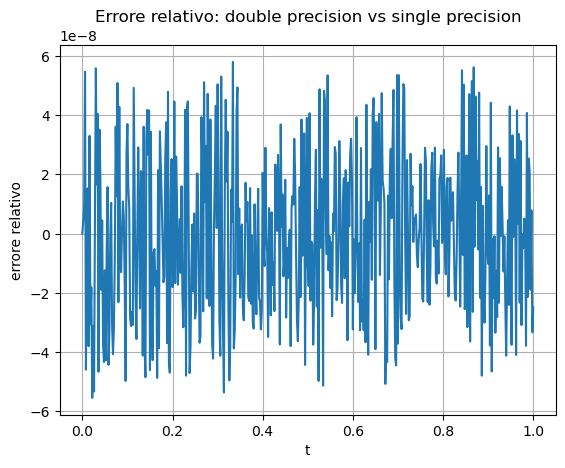

max errore relativo / eta_single = 0.9737441196931675


In [ ]:
t = np.linspace(0, 1, 501)

tt64 = np.exp(-t) * (np.sin(2*np.pi*t) + 2)
tt32 = tt64.astype(np.float32).astype(np.float64)

round_err = (tt64 - tt32) / tt64

plt.figure()
plt.plot(t, round_err)
plt.title("Errore relativo: double precision vs single precision")
plt.xlabel("t")
plt.ylabel("errore relativo")
plt.grid(True)
plt.show()

print("max errore relativo / eta_single =", np.max(np.abs(round_err)) / (np.finfo(np.float32).eps/2))

#### Lettura dell'errore relativo

I valori in single precision vengono convertiti nuovamente in double soltanto per misurare la differenza: la conversione non recupera le cifre già perdute. L'ampiezza tipica dell'errore relativo è dell'ordine di $10^{-8}$, coerente con l'unità di arrotondamento della single precision. Le oscillazioni rapide non rappresentano rumore di misura, ma i diversi arrotondamenti deterministici lungo la funzione campionata.


### 7. Distribuzione dei numeri floating-point

I numeri floating-point non sono uniformemente distribuiti.

La distanza assoluta fra due numeri consecutivi cresce con la grandezza del numero.

Invece, la distanza relativa resta circa controllata dall'unità di arrotondamento.

Tra $2^e$ e $2^{e+1}$, cioè all'interno della stessa **binade**, la distanza fra numeri normalizzati consecutivi è costante e vale circa

$$
\operatorname{ulp}(x)=2^{e-(t-1)}.
$$

Passando alla binade successiva, la distanza raddoppia. Per questo il sistema offre una precisione approssimativamente costante in senso relativo, non in senso assoluto. Il grafico di un sistema giocattolo rende visibile questa geometria.


In [ ]:
values = [1.0, 10.0, 1e6, 1e16]

for x in values:
    next_x = np.nextafter(x, np.inf)
    spacing = next_x - x
    print(f"x={x:.1e}, spacing={spacing:.3e}, spacing relativo={spacing/x:.3e}")

x=1.0e+00, spacing=2.220e-16, spacing relativo=2.220e-16
x=1.0e+01, spacing=1.776e-15, spacing relativo=1.776e-16
x=1.0e+06, spacing=1.164e-10, spacing relativo=1.164e-16
x=1.0e+16, spacing=2.000e+00, spacing relativo=2.000e-16


#### Distanza assoluta e distanza relativa

`np.nextafter(x, np.inf)` restituisce il primo floating-point maggiore di $x$. La differenza `next_x - x` cresce con $x$, mentre il rapporto tra questa differenza e $x$ resta vicino a `eps`. Attorno a $10^{16}$ la spaziatura è già dell'ordine delle unità: aggiungere $1$ può quindi non modificare affatto il valore memorizzato.


### 8. Sistema floating-point giocattolo

Costruiamo il sistema

$$
(\beta,t,L,U)=(2,3,-2,3).
$$

I numeri positivi normalizzati sono ottenuti da mantisse tra

$$
1.00_2
$$

e

$$
1.11_2
$$

e da esponenti da $-2$ a $3$.

Per ogni esponente ci sono quattro mantisse positive: $1.00_2$, $1.01_2$, $1.10_2$ e $1.11_2$. I punti sono equidistanti all'interno di ciascuna binade, ma la distanza raddoppia quando l'esponente aumenta. Senza numeri subnormali rimane inoltre un intervallo vuoto fra $0$ e il più piccolo numero normalizzato. Nei sistemi reali i subnormali riempiono gradualmente parte di questo intervallo e rendono l'underflow meno brusco.


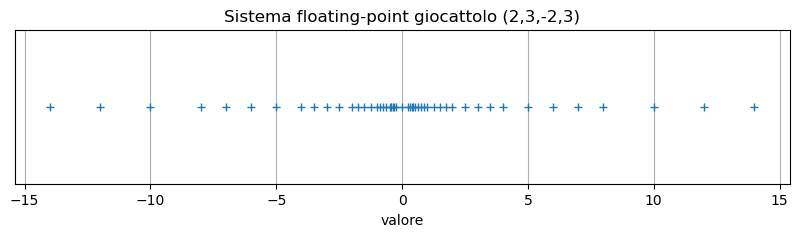

In [ ]:
def toy_floats(beta=2, t=3, L=-2, U=3):
    mantissas = []
    for frac in range(beta**(t-1)):
        mantissas.append(1 + frac / beta**(t-1))

    nums = []
    for m in mantissas:
        for e in range(L, U+1):
            nums.append(m * beta**e)

    nums = np.array(sorted(nums))
    return np.concatenate([-nums[::-1], [0.0], nums])

nums = toy_floats()

plt.figure(figsize=(10, 2))
plt.plot(nums, np.zeros_like(nums), "+")
plt.yticks([])
plt.grid(True)
plt.title("Sistema floating-point giocattolo (2,3,-2,3)")
plt.xlabel("valore")
plt.show()

#### Geometria del sistema giocattolo

Il grafico non deve essere letto come una distribuzione statistica. Ogni gruppo di punti corrisponde a un esponente; all'interno del gruppo la spaziatura è uniforme, poi raddoppia passando alla scala successiva. L'addensamento vicino a zero esprime una precisione relativa quasi costante. Il vuoto centrale ricorda che, nel modello normalizzato privo di subnormali, nessun valore positivo è rappresentabile tra zero e $\beta^L$.


## Parte II — Lo standard IEEE 754 e i valori speciali


### 9. Struttura di un numero in double precision

Un double IEEE 754 usa 64 bit:

| Campo | Bit |
|---|---:|
| segno | 1 |
| esponente | 11 |
| frazione | 52 |

Il valore normalizzato è

$$
(-1)^s(1+f)2^e.
$$

L'esponente memorizzato usa un bias:

$$
e=b-1023.
$$

Per i numeri normalizzati il campo esponente non usa tutti i suoi $2^{11}$ valori: i due pattern estremi sono riservati. Un esponente tutto zero rappresenta lo zero o i numeri subnormali; un esponente tutto uno rappresenta infinito o NaN. Per i numeri normalizzati double l'esponente reale varia quindi da $-1022$ a $1023$.

La formula $(-1)^s(1+f)2^e$ vale soltanto per i normalizzati. Nei subnormali il bit iniziale non è implicito e il significando ha forma $0+f$, permettendo una transizione graduale verso zero a prezzo di una precisione relativa ridotta.


In [ ]:
def float_to_bits(x):
    packed = struct.pack(">d", float(x))
    as_int = int.from_bytes(packed, byteorder="big")
    return format(as_int, "064b")

def explain_float64(x):
    bits = float_to_bits(x)
    sign_bit = bits[0]
    exponent_bits = bits[1:12]
    fraction_bits = bits[12:]

    sign = -1 if sign_bit == "1" else 1
    biased = int(exponent_bits, 2)
    exponent = biased - 1023

    frac = 0.0
    for i, bit in enumerate(fraction_bits, start=1):
        if bit == "1":
            frac += 2.0**(-i)

    reconstructed = sign * (1 + frac) * 2.0**exponent

    return bits, sign_bit, exponent_bits, fraction_bits, biased, exponent, frac, reconstructed

x = 488.0
bits, sign_bit, exponent_bits, fraction_bits, biased, exponent, frac, reconstructed = explain_float64(x)

print("x =", x)
print("bits =", bits)
print("segno =", sign_bit)
print("esponente memorizzato =", exponent_bits, "=", biased)
print("esponente reale =", exponent)
print("frazione =", frac)
print("ricostruito =", reconstructed)

x = 488.0
bits = 0100000001111110100000000000000000000000000000000000000000000000
segno = 0
esponente memorizzato = 10000000111 = 1031
esponente reale = 8
frazione = 0.90625
ricostruito = 488.0


#### Interpretare i 64 bit

La funzione separa il bit di segno, gli 11 bit dell'esponente e i 52 bit della frazione. Per un numero normalizzato, l'esponente reale si ottiene sottraendo il bias $1023$ e la mantissa inizia con un $1$ implicito. Provate valori come $1$, $1.5$, $2$ e $0.1$: i primi tre hanno una rappresentazione binaria breve, mentre $0.1$ mostra una frazione non nulla dovuta all'approssimazione della sua espansione infinita.


### 10. Overflow, underflow, infinito e NaN

**Overflow:** il risultato è troppo grande per essere rappresentato. Spesso produce `inf`.

**Underflow:** il risultato è troppo piccolo. Può produrre un numero subnormale o zero.

**NaN:** Not a Number, prodotto da operazioni indefinite come $0/0$.

Questi valori speciali permettono ai programmi di proseguire o segnalare problemi in modo controllato.

L'overflow è spesso più distruttivo dell'underflow: un valore finito diventa infinito e può contaminare molti passaggi successivi. L'underflow graduale, invece, può ancora produrre un piccolo numero subnormale e conservare parte dell'informazione. Se il valore scende ulteriormente, viene arrotondato a zero.

I valori speciali seguono regole precise: per esempio un numero finito diviso per zero può produrre $\pm\infty$, mentre operazioni indeterminate come $0/0$ o $\infty-\infty$ producono NaN. Un confronto con NaN è falso anche quando lo si confronta con se stesso; per individuarlo si usano funzioni come `np.isnan`.


In [ ]:
x = np.float64(1e308)
print("overflow:", x * 10)

small = np.float64(1e-308)
print("underflow verso zero:", small / 1e20)

a = np.array([0.0])
print("0/0:", a/a)

print("inf - inf:", np.inf - np.inf)

overflow: inf
underflow verso zero: 0.0
0/0: [nan]
inf - inf: nan


/var/folders/fn/ldzxtqdx50q1q6160qq33gtm0000gn/T/ipykernel_1874/1447149682.py:2: RuntimeWarning: overflow encountered in scalar multiply
  print("overflow:", x * 10)
/var/folders/fn/ldzxtqdx50q1q6160qq33gtm0000gn/T/ipykernel_1874/1447149682.py:8: RuntimeWarning: invalid value encountered in divide
  print("0/0:", a/a)


#### Perché non bisogna ignorare i valori speciali

NumPy emette avvisi ma continua il calcolo secondo le regole IEEE 754. Questo comportamento è utile nei calcoli vettoriali, ma richiede controlli espliciti: un `inf` può propagarsi e un NaN può rendere falsi i confronti successivi. In un algoritmo robusto si stabilisce se intercettare subito questi valori, sostituirli oppure restituire un messaggio diagnostico.


## Parte III — Cancellazione e formule stabili


### 11. Cancellazione numerica

La cancellazione avviene quando si sottraggono due numeri quasi uguali.

Se

$$
z=x-y
$$

con $x\approx y$, allora $z$ è piccolo.

Anche piccoli errori assoluti in $x$ e $y$ possono diventare grandi errori relativi in $z$ perché il denominatore $|x-y|$ è piccolo.

Se i valori memorizzati sono $\tilde{x}=x(1+\delta_x)$ e $\tilde{y}=y(1+\delta_y)$, l'errore nel numeratore della sottrazione è dell'ordine di $|x\delta_x|+|y\delta_y|$. Rapportato al risultato esatto, si ottiene un fattore di amplificazione simile a

$$
\frac{|x|+|y|}{|x-y|}.
$$

Quando $x\approx y$, il denominatore è piccolo e il fattore può essere enorme. La sottrazione non crea necessariamente un grande errore assoluto: rende grande l'errore **relativo** del risultato e fa emergere gli errori già presenti negli operandi.


In [ ]:
x = 1.000000000000001
y = 1.000000000000000
z = x - y

print("x =", format(x, ".17f"))
print("y =", format(y, ".17f"))
print("z =", format(z, ".17e"))

x = 1.00000000000000111
y = 1.00000000000000000
z = 1.11022302462515654e-15


### 12. Differenza di seni in forma stabile

Per evitare cancellazione in

$$
\sin(x_0+h)-\sin(x_0),
$$

usiamo l'identità

$$
\sin(\phi)-\sin(\psi)
=
2\cos\left(\frac{\phi+\psi}{2}\right)
\sin\left(\frac{\phi-\psi}{2}\right).
$$

Quindi

$$
\sin(x_0+h)-\sin(x_0)
=
2\cos\left(x_0+\frac{h}{2}\right)
\sin\left(\frac{h}{2}\right).
$$

Dividendo per $h$ si ottiene la formula

$$
\frac{\sin(x_0+h)-\sin(x_0)}{h}
=
\cos\left(x_0+\frac{h}{2}\right)
\frac{\sin(h/2)}{h/2}.
$$

Per $h\to0$, il secondo fattore tende a $1$. La forma riscritta evita di sottrarre due seni quasi uguali; per argomenti estremamente piccoli una funzione di libreria specializzata per $\sin z/z$ può migliorare ulteriormente il calcolo.


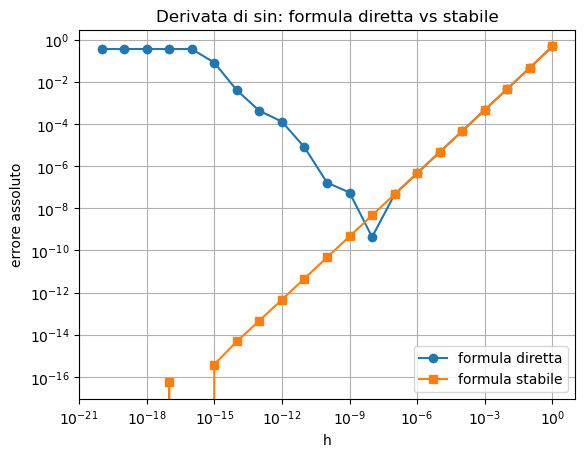

In [ ]:
def derivative_sin_naive(x0, h):
    return (math.sin(x0+h) - math.sin(x0)) / h

def derivative_sin_stable(x0, h):
    return 2 * math.cos(x0 + h/2) * math.sin(h/2) / h

x0 = 1.2
true_value = math.cos(x0)

hs = 10.0 ** np.arange(-20, 1)
err_naive = np.array([abs(true_value - derivative_sin_naive(x0, hh)) for hh in hs])
err_stable = np.array([abs(true_value - derivative_sin_stable(x0, hh)) for hh in hs])

plt.figure()
plt.loglog(hs, err_naive, marker="o", label="formula diretta")
plt.loglog(hs, err_stable, marker="s", label="formula stabile")
plt.title("Derivata di sin: formula diretta vs stabile")
plt.xlabel("h")
plt.ylabel("errore assoluto")
plt.grid(True, which="both")
plt.legend()
plt.show()

#### Confronto fra forma diretta e forma stabile

Per passi moderati le due formule coincidono entro l'errore di arrotondamento. Quando $h$ diventa molto piccolo, la differenza diretta dei seni perde cifre significative; la forma trigonometrica conserva invece il fattore piccolo come $\sin(h/2)$ senza ottenerlo per sottrazione. Il confronto con $\cos(x_0)$ rende visibile il guadagno di accuratezza.


### 13. Esempio: $\sqrt{x+1}-\sqrt{x}$

Per $x$ grande, la formula diretta

$$
\sqrt{x+1}-\sqrt{x}
$$

sottrae due numeri quasi uguali.

Moltiplicando e dividendo per il coniugato:

$$
\sqrt{x+1}-\sqrt{x}
=
\frac{1}{\sqrt{x+1}+\sqrt{x}}.
$$

La seconda formula è numericamente più stabile.

Le due espressioni sono identiche in aritmetica esatta ma non sul computer. Nella prima forma, le cifre comuni delle due radici si cancellano. Nella seconda compaiono soltanto somme e divisioni fra quantità della stessa scala, e non si perde informazione significativa. Questa è una strategia generale: usare un'identità algebrica per eliminare una sottrazione pericolosa.


In [ ]:
def sqrt_diff_naive(x):
    return math.sqrt(x + 1) - math.sqrt(x)

def sqrt_diff_stable(x):
    return 1 / (math.sqrt(x + 1) + math.sqrt(x))

for x in [1e5, 1e10, 1e15, 1e20]:
    naive = sqrt_diff_naive(x)
    stable = sqrt_diff_stable(x)
    print(f"x={x:.1e}")
    print("  diretta =", naive)
    print("  stabile =", stable)
    print("  differenza =", abs(naive - stable))

x=1.0e+05
  diretta = 0.001581134877255863
  stabile = 0.0015811348772568783
  differenza = 1.0152469143154264e-15
x=1.0e+10
  diretta = 4.999994416721165e-06
  stabile = 4.999999999875e-06
  differenza = 5.583153835188651e-12
x=1.0e+15
  diretta = 1.862645149230957e-08
  stabile = 1.5811388300841893e-08
  differenza = 2.8150631914676777e-09
x=1.0e+20
  diretta = 0.0
  stabile = 5e-11
  differenza = 5e-11


#### Che cosa mostra l'esperimento

All'aumentare di $x$, le due radici quadrate diventano sempre più vicine. La formula diretta può infine restituire zero perché i due operandi vengono arrotondati allo stesso numero. La formula razionalizzata rimane positiva e conserva l'ordine di grandezza corretto, circa $1/(2\sqrt{x})$.


### 14. La funzione $\sinh(x)$ vicino a zero

La formula

$$
\sinh(x)=\frac{e^x-e^{-x}}{2}
$$

può soffrire di cancellazione per $x$ vicino a zero.

Lo sviluppo di Taylor è

$$
\sinh(x)=x+\frac{x^3}{6}+\frac{x^5}{120}+\cdots.
$$

Per $|x|$ piccolo, pochi termini possono essere più accurati.

Non esiste una formula migliore per ogni valore di $x$. Per $x$ moderato la definizione esponenziale è adeguata; vicino a zero una serie o una funzione di libreria come `expm1`, progettata per calcolare $e^x-1$, evita la cancellazione. Una libreria robusta sceglie internamente la rappresentazione più accurata in base alla regione del dominio e tronca la serie quando il termine successivo è inferiore alla tolleranza richiesta.


In [ ]:
def sinh_direct(x):
    return 0.5 * (math.exp(x) - math.exp(-x))

def sinh_taylor3(x):
    return x + x**3 / 6

for x in [1e-1, 1e-5, 1e-10, 1e-15]:
    direct = sinh_direct(x)
    tay = sinh_taylor3(x)
    exact = math.sinh(x)
    print(f"x={x:.1e}")
    print("  errore formula diretta =", abs(direct - exact))
    print("  errore Taylor =", abs(tay - exact))

x=1.0e-01
  errore formula diretta = 6.938893903907228e-17
  errore Taylor = 8.335317736030134e-08
x=1.0e-05
  errore formula diretta = 4.5644911461639737e-17
  errore Taylor = 0.0
x=1.0e-10
  errore formula diretta = 8.274037096265818e-18
  errore Taylor = 0.0
x=1.0e-15
  errore formula diretta = 5.4711873393898636e-17
  errore Taylor = 0.0


#### Scelta della formula in base alla scala

La serie cubica è accurata soltanto quando i termini trascurati, a partire da $x^5/120$, sono piccoli rispetto alla precisione richiesta. Per valori non piccoli deve essere preferita una formula di libreria. L'esempio non suggerisce di sostituire sempre `sinh` con tre termini di Taylor, ma di evitare una sottrazione instabile nella regione in cui esiste un'approssimazione locale controllata.


## Parte IV — Calcolo stabile delle radici quadratiche


### 15. Formula standard e problema di cancellazione

Per

$$
x^2-2bx+c=0
$$

le radici sono

$$
x_{1,2}=b\pm\sqrt{b^2-c}.
$$

Se $b^2$ è molto più grande di $c$, una delle due formule contiene una sottrazione tra quantità quasi uguali.

Si può usare la relazione

$$
x_1x_2=c
$$

per calcolare in modo stabile la radice piccola.

Supponiamo per esempio $b>0$. La radice $b+\sqrt{b^2-c}$ è calcolata senza cancellazione, mentre $b-\sqrt{b^2-c}$ è la differenza di due numeri quasi uguali. Si calcola quindi prima la radice grande

$$
x_1=b+\sqrt{b^2-c}
$$

e poi la radice piccola usando il prodotto delle radici:

$$
x_2=\frac{c}{x_1}.
$$

Per $b<0$ si sceglie il segno opposto. Il principio è sempre lo stesso: calcolare direttamente la combinazione che somma quantità concordi e ricavare l'altra radice da una relazione esatta.


In [ ]:
def roots_standard_b(b, c):
    d = math.sqrt(b*b - c)
    return b + d, b - d

def roots_stable_b(b, c):
    d = math.sqrt(b*b - c)
    if b > 0:
        x1 = b + d
        x2 = c / x1
    else:
        x2 = b - d
        x1 = c / x2
    return x1, x2

b = 1e8
c = 1.0

x1s, x2s = roots_standard_b(b, c)
x1r, x2r = roots_stable_b(b, c)

print("standard:", x1s, x2s)
print("stabile :", x1r, x2r)
print("prodotto standard:", x1s*x2s)
print("prodotto stabile :", x1r*x2r)

standard: 200000000.0 0.0
stabile : 200000000.0 5e-09
prodotto standard: 0.0
prodotto stabile : 1.0


### 16. Equazione quadratica generale

Per

$$
ax^2+bx+c=0
$$

la formula standard è

$$
x_{1,2}
=
\frac{-b\pm\sqrt{b^2-4ac}}{2a}.
$$

Una forma più stabile usa

$$
q=-\frac{1}{2}\left(b+\mathrm{sign}(b)\sqrt{b^2-4ac}\right),
$$

poi

$$
x_1=\frac{q}{a},
\qquad
x_2=\frac{c}{q}.
$$

La scelta di `sign(b)` fa sì che in $q$ i due termini abbiano lo stesso segno, evitando la cancellazione. La formula richiede comunque controlli per casi particolari: $a=0$, discriminante negativo, $q=0$ e possibili overflow nel calcolo di $b^2-4ac$. Le implementazioni di produzione possono scalare i coefficienti o usare operazioni più robuste per il discriminante.

La stabilità numerica non consiste quindi nel sostituire meccanicamente una formula con un'altra, ma nel gestire in modo coerente tutti i rami del problema.


In [ ]:
def quadratic_standard(a, b, c):
    if a == 0:
        return [-c/b] if b != 0 else []
    disc = b*b - 4*a*c
    if disc < 0:
        return []
    s = math.sqrt(disc)
    return [(-b + s)/(2*a), (-b - s)/(2*a)]

def quadratic_stable(a, b, c):
    if a == 0:
        return [-c/b] if b != 0 else []
    disc = b*b - 4*a*c
    if disc < 0:
        return []
    s = math.sqrt(disc)
    if b >= 0:
        q = -0.5 * (b + s)
    else:
        q = -0.5 * (b - s)

    x1 = q / a
    x2 = c / q if q != 0 else 0.0
    return [x1, x2]

cases = [
    (1.0, -1e8, 1.0),
    (1.0, 1e8, 1.0),
    (1.0, -2.0, 1e-12),
]

for a, b, c in cases:
    print("\nCaso:", a, b, c)
    print("standard:", quadratic_standard(a,b,c))
    print("stabile :", quadratic_stable(a,b,c))


Caso: 1.0 -100000000.0 1.0
standard: [100000000.0, 7.450580596923828e-09]
stabile : [100000000.0, 1e-08]

Caso: 1.0 100000000.0 1.0
standard: [-7.450580596923828e-09, -100000000.0]
stabile : [-100000000.0, -1e-08]

Caso: 1.0 -2.0 1e-12
standard: [1.9999999999995, 5.000444502911705e-13]
stabile : [1.9999999999995, 5.00000000000125e-13]


#### Verifica delle radici

Oltre a confrontare le due implementazioni, si possono usare le identità di Viète

$$
x_1+x_2=-\frac{b}{a},
\qquad
x_1x_2=\frac{c}{a}.
$$

Quando una radice è molto più piccola dell'altra, il prodotto è spesso un controllo più sensibile della piccola radice rispetto alla semplice sostituzione nel polinomio. Anche i controlli numerici devono però essere interpretati tenendo conto della scala dei coefficienti.


## Parte V — Progettazione di funzioni di libreria robuste


### 17. Norma euclidea e overflow

La norma euclidea è

$$
\|x\|_2=\sqrt{x_1^2+\cdots+x_n^2}.
$$

Una formula ingenua può generare overflow calcolando i quadrati, anche quando la norma finale è rappresentabile.

Per evitare il problema, si scala il vettore con

$$
s=\max_i |x_i|.
$$

Allora

$$
\|x\|_2
=
s\sqrt{\sum_i\left(\frac{x_i}{s}\right)^2}.
$$

Poiché $|x_i/s|\le1$, i quadrati nella somma scalata non possono andare in overflow. La moltiplicazione finale per $s$ ricostruisce la scala corretta. La stessa idea protegge anche dall'underflow quando le componenti sono molto piccole. Se $s=0$, il vettore è nullo e la norma deve essere restituita direttamente come zero.

Una funzione di libreria può usare strategie ancora più raffinate per sommare i quadrati, ma il ridimensionamento mostra già perché una formula matematicamente ovvia non è sempre una buona implementazione.


In [ ]:
def norm2_naive(x):
    x = np.asarray(x, dtype=float)
    return math.sqrt(np.sum(x*x))

def norm2_stable(x):
    x = np.asarray(x, dtype=float)
    s = np.max(np.abs(x))
    if s == 0:
        return 0.0
    y = x / s
    return s * math.sqrt(np.sum(y*y))

vectors = [
    np.array([3.0, 4.0]),
    np.array([1e200, 1.0]),
    np.array([1e-200, 1e-200]),
]

for v in vectors:
    print("v =", v)
    try:
        print("  naive:", norm2_naive(v))
    except Exception as e:
        print("  naive errore:", e)
    print("  stabile:", norm2_stable(v))
    print("  numpy:", np.linalg.norm(v))

v = [3. 4.]
  naive: 5.0
  stabile: 5.0
  numpy: 5.0
v = [1.e+200 1.e+000]
  naive: inf
  stabile: 1e+200
  numpy: inf
v = [1.e-200 1.e-200]
  naive: 0.0
  stabile: 1.414213562373095e-200
  numpy: 0.0


/var/folders/fn/ldzxtqdx50q1q6160qq33gtm0000gn/T/ipykernel_1874/3965678213.py:3: RuntimeWarning: overflow encountered in multiply
  return math.sqrt(np.sum(x*x))
/opt/anaconda3/envs/prova/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


#### Risultato della norma scalata

Nel calcolo ingenuo i quadrati possono superare `float64.max` e produrre infinito, anche se la radice quadrata finale sarebbe rappresentabile. La versione scalata mantiene i rapporti $x_i/s$ nell'intervallo $[-1,1]$ e restituisce una norma finita. L'esempio mostra che evitare risultati intermedi estremi è una parte essenziale della progettazione numerica.


### 18. Varianza e cancellazione

La varianza può essere calcolata come

$$
s^2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^2
$$

oppure come

$$
s^2=\frac{1}{n}\sum_{i=1}^{n}x_i^2-\bar{x}^2.
$$

La seconda formula può essere meno accurata se i dati sono grandi ma la varianza è piccola, perché sottrae due numeri quasi uguali.

Nella seconda formula, sia $\frac{1}{n}\sum x_i^2$ sia $\bar{x}^2$ possono essere dell'ordine di $10^{16}$, mentre la loro differenza è dell'ordine di $1$. Quasi tutte le cifre significative devono quindi cancellarsi. Gli errori di arrotondamento presenti nei due termini possono diventare più grandi della varianza stessa e produrre perfino un valore negativo.

La formula centrata in due passaggi è in genere molto più stabile. Quando i dati arrivano in streaming, si può usare l'algoritmo incrementale di Welford, che aggiorna media e somma degli scarti senza formare la differenza fra due quantità enormi.


In [ ]:
rng = np.random.default_rng(0)
data = 1e8 + rng.normal(scale=1.0, size=100000)

mean = np.mean(data)

var_stable = np.mean((data - mean)**2)
var_unstable = np.mean(data**2) - mean**2

print("varianza stabile:", var_stable)
print("formula alternativa:", var_unstable)
print("differenza:", var_unstable - var_stable)

varianza stabile: 1.000257024601711
formula alternativa: 2.0
differenza: 0.9997429753982889


#### Risultato della varianza

I dati sono concentrati attorno a $10^8$, ma le loro deviazioni dalla media sono dell'ordine di $1$. La formula a un passaggio sottrae due quantità dell'ordine di $10^{16}$ per ricavare un risultato dell'ordine di $1$: è una configurazione ideale per la cancellazione. La formula centrata lavora direttamente con le deviazioni e conserva molte più cifre significative.


## Parte VI — Esercizi di laboratorio


### Esercizio 1 — Differenziazione numerica

Ripetere lo studio dell'errore della differenza in avanti e della differenza centrata per

$$
f(x)=\cos(x),
\qquad
x_0=0.7.
$$

Produrre un grafico log-log degli errori.


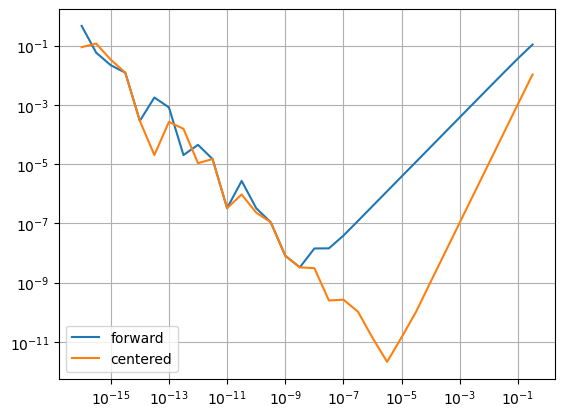

In [ ]:
# Spazio di lavoro

x0 = 0.7
true_derivative = -math.sin(x0)
hs = 10.0 ** np.arange(-16, 0, 0.5)

err_fwd = np.array([abs(true_derivative - forward_difference(math.cos, x0, h)) for h in hs])
err_ctr = np.array([abs(true_derivative - centered_difference(math.cos, x0, h)) for h in hs])

plt.figure()
plt.loglog(hs, err_fwd, label="forward")
plt.loglog(hs, err_ctr, label="centered")
plt.grid(True, which="both")
plt.legend()
plt.show()

### Esercizio 2 — Condizionamento di $\tanh(cx)$

Studiare

$$
g(x)=\tanh(cx)
$$

vicino a $x=0$ per valori crescenti di $c$.

Suggerimento:

$$
g'(0)=c.
$$

Cosa succede al condizionamento quando $c$ cresce?


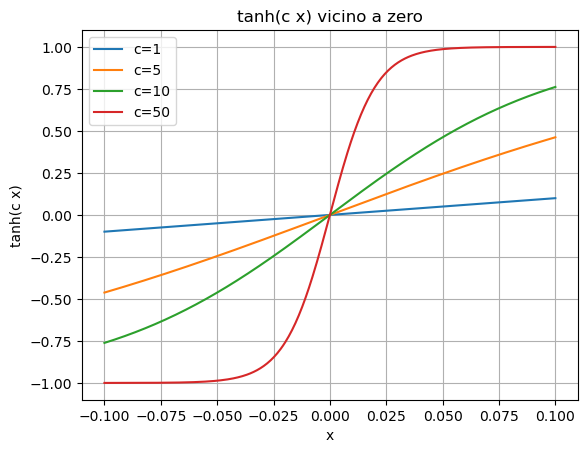

In [ ]:
# Spazio di lavoro

xs = np.linspace(-0.1, 0.1, 400)

plt.figure()
for c in [1, 5, 10, 50]:
    plt.plot(xs, np.tanh(c*xs), label=f"c={c}")
plt.title("tanh(c x) vicino a zero")
plt.xlabel("x")
plt.ylabel("tanh(c x)")
plt.grid(True)
plt.legend()
plt.show()

### Esercizio 3 — Unità di arrotondamento

Scrivere una funzione che stimi il più piccolo $\varepsilon$ tale che

$$
1+\varepsilon>1.
$$

Confrontare il risultato con `np.finfo(float).eps`.


In [ ]:
# Spazio di lavoro

def estimate_eps():
    eps = 1.0
    while 1.0 + eps/2 > 1.0:
        eps /= 2
    return eps

eps_est = estimate_eps()
print("eps stimato:", eps_est)
print("eps NumPy:", np.finfo(float).eps)

eps stimato: 2.220446049250313e-16
eps NumPy: 2.220446049250313e-16


### Esercizio 4 — Sistema floating-point giocattolo

Generare e rappresentare tutti i numeri del sistema

$$
(\beta,t,L,U)=(2,4,-3,3).
$$

Dove sono più densi?


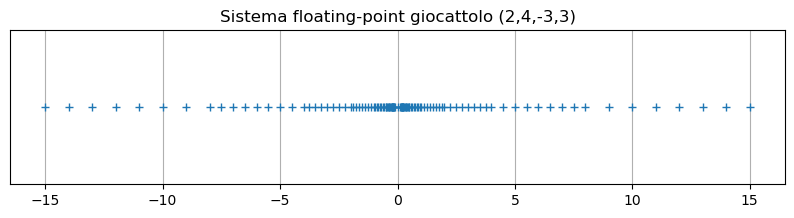

In [ ]:
# Spazio di lavoro

nums = toy_floats(beta=2, t=4, L=-3, U=3)

plt.figure(figsize=(10, 2))
plt.plot(nums, np.zeros_like(nums), "+")
plt.yticks([])
plt.grid(True)
plt.title("Sistema floating-point giocattolo (2,4,-3,3)")
plt.show()

### Esercizio 5 — Cancellazione nella differenza di coseni

Usare l'identità

$$
\cos(\phi)-\cos(\psi)
=
-2\sin\left(\frac{\phi+\psi}{2}\right)
\sin\left(\frac{\phi-\psi}{2}\right)
$$

per calcolare in modo stabile

$$
\frac{\cos(x+\delta)-\cos(x)}{\delta}.
$$

Confrontare con la formula diretta per $x=3$ e $\delta=10^{-11}$.


In [ ]:
# Spazio di lavoro

def cos_diff_naive(x, delta):
    return (math.cos(x + delta) - math.cos(x)) / delta

def cos_diff_stable(x, delta):
    return -2 * math.sin(x + delta/2) * math.sin(delta/2) / delta

x = 3.0
delta = 1e-11
true_value = -math.sin(x)

naive = cos_diff_naive(x, delta)
stable = cos_diff_stable(x, delta)

print("valore atteso:", true_value)
print("formula diretta:", naive, "errore:", abs(naive - true_value))
print("formula stabile:", stable, "errore:", abs(stable - true_value))

valore atteso: -0.1411200080598672
formula diretta: -0.14112044866010365 errore: 4.4060023643432977e-07
formula stabile: -0.14112000805491726 errore: 4.949957110866876e-12


### Esercizio 6 — Radici quadratiche

Confrontare la formula standard e quella stabile sui casi:

$$
x^2-10^8x+1=0,
$$

$$
x^2+10^8x+1=0.
$$


In [ ]:
# Spazio di lavoro

for a, b, c in [(1.0, -1e8, 1.0), (1.0, 1e8, 1.0)]:
    print("caso:", a, b, c)
    print("standard:", quadratic_standard(a,b,c))
    print("stabile:", quadratic_stable(a,b,c))

caso: 1.0 -100000000.0 1.0
standard: [100000000.0, 7.450580596923828e-09]
stabile: [100000000.0, 1e-08]
caso: 1.0 100000000.0 1.0
standard: [-7.450580596923828e-09, -100000000.0]
stabile: [-100000000.0, -1e-08]


### Esercizio 7 — Somma in ordine crescente e decrescente

Sommare

$$
\sum_{n=1}^{10000}\frac{1}{n}
$$

in ordine crescente e decrescente.

Confrontare i risultati.


In [ ]:
# Spazio di lavoro

n = 10000
values = 1 / np.arange(1, n+1, dtype=float)

sum_desc = np.sum(values)
sum_asc = np.sum(values[::-1])

print("somma da grande a piccolo:", format(sum_desc, ".17f"))
print("somma da piccolo a grande:", format(sum_asc, ".17f"))
print("differenza:", sum_asc - sum_desc)

somma da grande a piccolo: 9.78760603604438195
somma da piccolo a grande: 9.78760603604438373
differenza: 1.7763568394002505e-15


## Parte VII — Riepilogo finale


### Checklist dei concetti principali

Al termine della lezione dovreste saper spiegare:

1. la differenza fra calcolo scientifico e analisi numerica;
2. errore assoluto e relativo;
3. errori nel problema, di discretizzazione, di convergenza e di arrotondamento;
4. perché la differenza in avanti ha errore $O(h)$;
5. perché la differenza centrata ha errore $O(h^2)$;
6. perché l'errore può aumentare quando $h$ è troppo piccolo;
7. accuratezza, efficienza e robustezza;
8. differenza fra condizionamento e stabilità;
9. cosa significa crescita lineare o esponenziale degli errori;
10. come funziona una rappresentazione floating-point;
11. cosa misura l'unità di arrotondamento;
12. cosa sono overflow, underflow e NaN;
13. perché la cancellazione è pericolosa;
14. come riscrivere formule per renderle più stabili;
15. perché i confronti floating-point devono usare tolleranze.

Per verificare una comprensione realmente autonoma, provate inoltre a rispondere senza eseguire il codice:

- perché $1+2^{-53}$ può essere ancora uguale a $1$ in double precision?
- perché due formule algebricamente equivalenti possono restituire risultati diversi?
- in quale regione di un grafico errore-passo domina la discretizzazione e in quale domina il roundoff?
- perché un residuo piccolo non garantisce una soluzione accurata per un problema mal condizionato?
- quale differenza c'è fra la distanza assoluta e la distanza relativa di due floating-point consecutivi?
- come si riconosce una sottrazione potenzialmente soggetta a cancellazione?

Se le risposte collegano definizioni, formule ed esperimenti, i concetti principali del capitolo sono stati acquisiti.


### Glossario

**Errore assoluto:** $|u-v|$.

**Errore relativo:** $|u-v|/|u|$.

**Errore di discretizzazione:** errore dovuto alla sostituzione di un problema continuo con uno discreto.

**Errore di convergenza:** errore dovuto all'arresto di un metodo iterativo.

**Errore di arrotondamento:** errore dovuto alla rappresentazione finita dei numeri.

**Accuratezza:** vicinanza del risultato alla soluzione esatta.

**Efficienza:** costo computazionale di un algoritmo.

**Robustezza:** capacità di un algoritmo di funzionare in modo affidabile.

**Condizionamento:** sensibilità del problema alle perturbazioni dei dati.

**Stabilità:** capacità dell'algoritmo di non amplificare eccessivamente gli errori.

**Floating-point:** rappresentazione a virgola mobile.

**Mantissa:** parte significativa del numero floating-point.

**Esponente:** parte che determina l'ordine di grandezza.

**Unità di arrotondamento:** limite superiore tipico dell'errore relativo di rappresentazione.

**Cancellazione:** perdita di cifre significative nella sottrazione di numeri quasi uguali.

**Overflow:** risultato troppo grande per essere rappresentato.

**Underflow:** risultato troppo piccolo per essere rappresentato come normalizzato.

**NaN:** Not a Number.

**Horner:** metodo efficiente per valutare polinomi.

**FMA:** fused multiply-add, operazione $fl(xy+z)$ con un solo arrotondamento.
